# Task 3 - Analytics Charts
**BMIT3003 Data Warehouse Technology** - Domain C (YV): Customer, Membership & Loyalty

Run every cell top to bottom. Charts land in `Task 3 output/Yong Vay/`.

---

### How this notebook gets its numbers

It **queries the warehouse directly** rather than holding transcribed figures. Re-run
the ETL and re-run this notebook and the charts follow; there is nothing to update by
hand and nothing that can silently go stale.

If you would rather not install the driver, Cell 2 falls back to reading CSVs exported
from SQL\*Plus - see the instructions in that cell.

### Four rules baked into these charts

1. **2026 is January-August only.** Where it appears it is hatched and labelled, and it
   is excluded from every year-on-year calculation.
2. **Headcounts use `customer_id`, never `customer_key`.** `customer_dim` is Type 2, so
   a customer who upgraded tier owns more than one surrogate key.
3. **Redemptions are sparse and late-clustered** in this source, so the monthly
   earn-versus-redeem chart starts at the all-branches era and the liability charts
   carry no time axis at all.
4. **Colour is the same CVD-validated categorical palette** used in Domain A, assigned
   in fixed slot order, so both chapters of the compiled report look like one document.

## 1 - Setup

Imports, the shared palette, and a matplotlib style tuned for print. Charts save at
220 DPI so they stay sharp when placed in a Word document.

In [1]:
# %% ===========================  CELL 1 - SETUP  =============================
import os
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

OUT = os.path.join("..", "..", "Task 3 output", "Yong Vay")
os.makedirs(OUT, exist_ok=True)

# --- Validated categorical palette (fixed slot order, never cycled) ----------
# Identical to Domain A so the compiled report reads as one document.
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"      # blue, orange, aqua
RED, BLUE  = "#e34948", "#2a78d6"                  # diverging pair
INK        = "#1a1a19"
INK_SOFT   = "#52514e"
INK_MUTE   = "#8a8985"
GRID       = "#e6e5e1"
SURFACE    = "#ffffff"

# Fixed tier -> colour map, so a tier is the same colour on every chart.
TIER_COLOUR = {"VIP": C1, "Normal": C2, "Non-Member": INK_MUTE, "Unknown": GRID}

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 220,                 # print-quality for a Word report
    "savefig.bbox": "tight",
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "font.family": ["DejaVu Sans"],
    "font.size": 10,
    "axes.edgecolor": GRID,
    "axes.linewidth": 0.8,
    "axes.labelcolor": INK_SOFT,
    "axes.titlesize": 12.5,
    "axes.titleweight": "bold",
    "axes.titlecolor": INK,
    "axes.titlepad": 14,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": INK_SOFT,
    "ytick.color": INK_SOFT,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.frameon": False,
    "legend.fontsize": 9.5,
})


def clean(ax, xgrid=False, ygrid=True):
    """Recessive axes: drop the box, keep one grid direction."""
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.xaxis.grid(xgrid)
    ax.yaxis.grid(ygrid)
    ax.tick_params(length=0)


def subtitle(ax, text):
    """Call AFTER set_title. Re-pads the title so the two never collide."""
    ax.set_title(ax.get_title(), pad=30)
    ax.text(0, 1.012, text, transform=ax.transAxes, fontsize=9.5,
            color=INK_MUTE, ha="left", va="bottom")


rm  = FuncFormatter(lambda v, p: f"{v:,.0f}")
pct = FuncFormatter(lambda v, p: f"{v:.0f}%")


def save(fig, name):
    path = os.path.join(OUT, name + ".png")
    fig.savefig(path, facecolor=SURFACE)
    print("saved " + path)


PART_YEAR = 2026    # January-August only
ERA_YEAR  = 2024    # all twelve branches trading from here

print("Setup complete.")

Setup complete.


## 2 - Connect to the warehouse

Thin-mode `oracledb` needs no Oracle Instant Client - it is a pure-Python driver. If the
import fails, run this in a terminal:

```
pip install oracledb
```

**Fallback without the driver.** Set `USE_CSV = True` below, then in SQL\*Plus as the DW
user export each query to `Task 3 output/Yong Vay/csv/<name>.csv`:

```
SET MARKUP CSV ON
SET PAGESIZE 50000
SET FEEDBACK OFF
SET TRIMSPOOL ON
SPOOL "…/Task 3 output/Yong Vay/csv/tier_value.csv"
<paste the query from the matching cell below>
SPOOL OFF
```

The `q()` helper reads the CSV when `USE_CSV` is on and runs the SQL when it is off, so
every chart cell below works either way without modification.

In [2]:
# %% ========================  CELL 2 - CONNECTION  ===========================
USE_CSV  = False                                  # True to read exported CSVs instead
CSV_DIR  = os.path.join(OUT, "csv")

DW_USER  = "dw"
DW_DSN   = "localhost:1521/FREEPDB1"              # adjust to your service name

_conn = None
if not USE_CSV:
    import getpass
    import oracledb                                # pip install oracledb
    _conn = oracledb.connect(
        user=DW_USER,
        password=getpass.getpass(f"Password for {DW_USER}: "),
        dsn=DW_DSN,
    )
    print("Connected:", _conn.version)


def q(name, sql):
    """Return a DataFrame for one exhibit, from Oracle or from a saved CSV.

    `name` is both the CSV filename and the cache key, so switching USE_CSV
    changes nothing else in the notebook.
    """
    if USE_CSV:
        df = pd.read_csv(os.path.join(CSV_DIR, name + ".csv"))
    else:
        df = pd.read_sql(sql, _conn)
    df.columns = [c.upper() for c in df.columns]
    return df


# --- Part-year label, derived from the data rather than hardcoded ------------
# The source generator is SYSDATE-dependent, so a literal "Jan-Aug" goes stale
# on its own. Same principle as Report 3's as-at date: anchor to the warehouse,
# never to the wall clock.
AS_OF = None
if _conn is not None:
    AS_OF = pd.to_datetime(pd.read_sql(
        "SELECT MAX(d.cal_date) AS as_of "
        "FROM sales_fact s JOIN date_dim d ON d.date_key = s.order_date_key",
        _conn)["AS_OF"].iloc[0])
    print("Warehouse data runs to:", AS_OF.date())

if AS_OF is not None:
    PART_YEAR_NOTE = (f"{PART_YEAR} is a part year" + "\n"
                      + f"(to {AS_OF.day} {AS_OF:%b})")
else:
    PART_YEAR_NOTE = f"{PART_YEAR} is a part year"


Connected: 23.26.2.0.0
Warehouse data runs to: 2026-09-02


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20708\3712593257.py:40: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  AS_OF = pd.to_datetime(pd.read_sql(


## 3 - Report 1: Membership tier economics

**Chart c1_1** spend per customer against average order value, by tier. Two bars per tier
because they answer different questions - AOV is how big a visit is, spend per customer
folds in how often they come back.

**Chart c1_2** each tier's share of net sales, as a donut. A pie is defensible here and
only here: three mutually exclusive parts of one whole.

In [3]:
# %% =================  CELL 3 - R1 DATA: TIER SCORECARD  =====================
tier = q("tier_value", """
    WITH tier_sales AS (
        SELECT c.membership_type,
               COUNT(DISTINCT c.customer_id) AS customers,
               COUNT(DISTINCT s.order_no)    AS orders,
               SUM(s.net_sales_amt)          AS net_sales
        FROM   sales_fact   s
        JOIN   customer_dim c ON c.customer_key = s.customer_key
        WHERE  c.customer_key <> -1
        GROUP  BY c.membership_type
    )
    SELECT membership_type,
           customers,
           orders,
           ROUND(orders / NULLIF(customers,0), 2)              AS orders_per_cust,
           ROUND(net_sales)                                    AS net_sales,
           ROUND(100 * net_sales / SUM(net_sales) OVER (), 1)   AS sales_share_pct,
           ROUND(net_sales / NULLIF(orders,0), 2)               AS avg_order_value,
           ROUND(net_sales / NULLIF(customers,0), 2)            AS spend_per_cust
    FROM   tier_sales
    ORDER  BY spend_per_cust DESC
""")
tier

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20708\3712593257.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, _conn)


,MEMBERSHIP_TYPE,CUSTOMERS,ORDERS,ORDERS_PER_CUST,NET_SALES,SALES_SHARE_PCT,AVG_ORDER_VALUE,SPEND_PER_CUST
0,Normal,354,2780,7.85,215351,38.4,77.46,608.34
1,VIP,292,2216,7.59,169080,30.2,76.30,579.04
2,Non-Member,348,2366,6.80,175847,31.4,74.32,505.31


saved ..\..\Task 3 output\Yong Vay\c1_1_tier_value.png


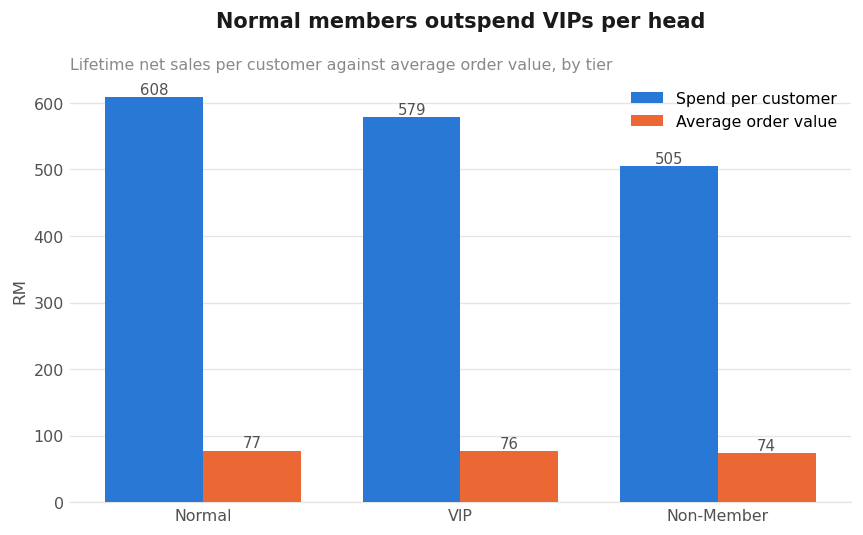

In [4]:
# %% ============  CELL 4 - CHART c1_1: SPEND PER CUSTOMER vs AOV  ============
d = tier.sort_values("SPEND_PER_CUST", ascending=False)
x = np.arange(len(d))
w = 0.38

fig, ax = plt.subplots(figsize=(8.4, 4.6))
ax.bar(x - w/2, d["SPEND_PER_CUST"], w, label="Spend per customer",
       color=C1, zorder=3)
ax.bar(x + w/2, d["AVG_ORDER_VALUE"], w, label="Average order value",
       color=C2, zorder=3)

for xi, (sp, ao) in enumerate(zip(d["SPEND_PER_CUST"], d["AVG_ORDER_VALUE"])):
    ax.text(xi - w/2, sp, f"{sp:,.0f}", ha="center", va="bottom",
            fontsize=9, color=INK_SOFT)
    ax.text(xi + w/2, ao, f"{ao:,.0f}", ha="center", va="bottom",
            fontsize=9, color=INK_SOFT)

ax.set_xticks(x)
ax.set_xticklabels(d["MEMBERSHIP_TYPE"])
ax.yaxis.set_major_formatter(rm)
ax.set_ylabel("RM")
ax.set_title("Normal members outspend VIPs per head")
subtitle(ax, "Lifetime net sales per customer against average order value, by tier")
ax.legend(loc="upper right")
clean(ax)
save(fig, "c1_1_tier_value")
plt.show()

saved ..\..\Task 3 output\Yong Vay\c1_2_sales_share.png


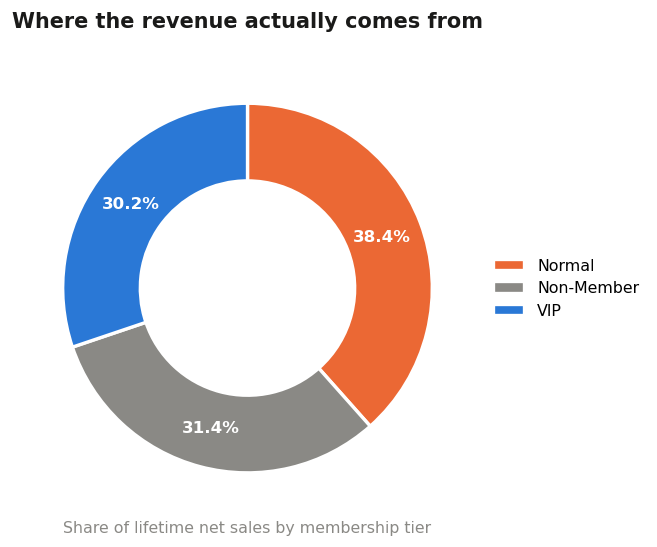

In [5]:
# %% ================  CELL 5 - CHART c1_2: SHARE OF NET SALES  ===============
d = tier.sort_values("NET_SALES", ascending=False)
colours = [TIER_COLOUR.get(t, GRID) for t in d["MEMBERSHIP_TYPE"]]

fig, ax = plt.subplots(figsize=(6.4, 5.0))
wedges, _, autotexts = ax.pie(
    d["NET_SALES"], colors=colours, startangle=90, counterclock=False,
    autopct=lambda p: f"{p:.1f}%", pctdistance=0.78,
    wedgeprops=dict(width=0.42, edgecolor=SURFACE, linewidth=2),
)
for t in autotexts:
    t.set_color(SURFACE)
    t.set_fontsize(10)
    t.set_fontweight("bold")

ax.legend(wedges, d["MEMBERSHIP_TYPE"], loc="center left",
          bbox_to_anchor=(1.0, 0.5))
ax.set_title("Where the revenue actually comes from", pad=18)
ax.text(0, -1.32, "Share of lifetime net sales by membership tier",
        ha="center", fontsize=9.5, color=INK_MUTE, transform=ax.transData)
ax.set_aspect("equal")
save(fig, "c1_2_sales_share")
plt.show()

**Chart c1_3** revenue by tier by year, stacked. Because `customer_dim` is Type 2, a
customer who upgraded mid-decade sits under Normal in the early years and VIP in the
later ones - the shifting mix is the dimension doing real work, not a data error.

**Chart c1_4** year-on-year growth per tier. 2026 is dropped: a part year cannot carry a
growth percentage.

In [6]:
# %% ===============  CELL 6 - R1 DATA: TIER BY YEAR  =========================
tier_yr = q("tier_by_year", """
    SELECT d.cal_year,
           c.membership_type,
           COUNT(DISTINCT s.order_no)  AS orders,
           ROUND(SUM(s.net_sales_amt)) AS net_sales
    FROM   sales_fact   s
    JOIN   customer_dim c ON c.customer_key = s.customer_key
    JOIN   date_dim     d ON d.date_key     = s.order_date_key
    WHERE  c.customer_key <> -1
    GROUP  BY d.cal_year, c.membership_type
    ORDER  BY d.cal_year
""")

pivot = (tier_yr.pivot(index="CAL_YEAR", columns="MEMBERSHIP_TYPE",
                       values="NET_SALES")
                .fillna(0).sort_index())
pivot

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20708\3712593257.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, _conn)


MEMBERSHIP_TYPE,Non-Member,Normal,VIP
CAL_YEAR,,,
2016,6014,4703,3621
2017,6982,5878,6295
2018,9709,10196,6196
2019,11274,12169,8701
2020,6918,7410,5312
2021,10186,10034,7993
2022,17965,15894,13823
2023,27078,27250,19371
2024,23672,38797,30554


saved ..\..\Task 3 output\Yong Vay\c1_3_tier_by_year.png


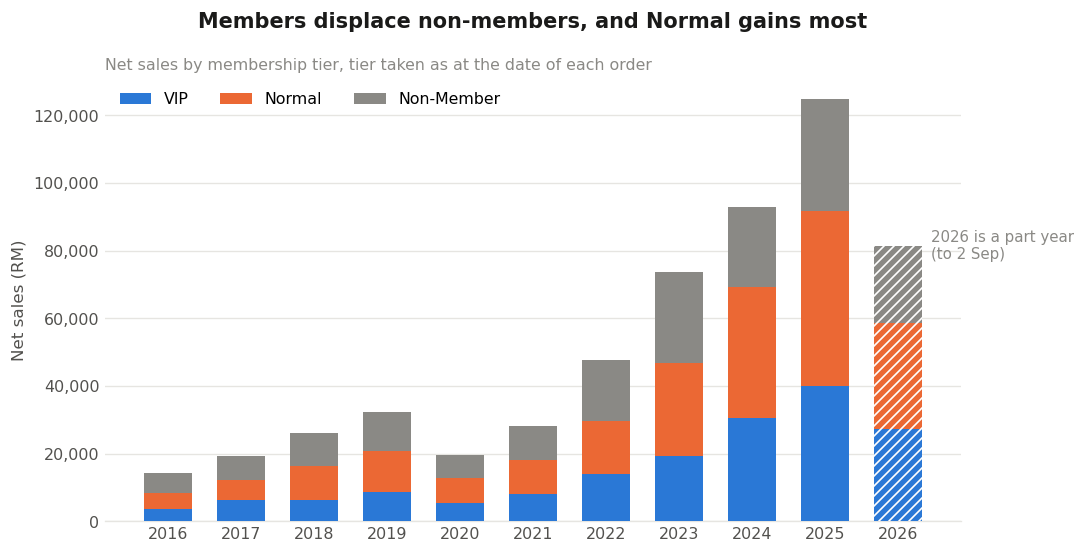

In [7]:
# %% =============  CELL 7 - CHART c1_3: REVENUE BY TIER BY YEAR  =============
years = pivot.index.to_list()
order = [t for t in ("VIP", "Normal", "Non-Member", "Unknown") if t in pivot.columns]

fig, ax = plt.subplots(figsize=(9.2, 4.8))
bottom = np.zeros(len(years))
for t in order:
    vals = pivot[t].to_numpy(dtype=float)
    ax.bar(years, vals, 0.66, bottom=bottom, label=t,
           color=TIER_COLOUR.get(t, GRID), zorder=3)
    bottom += vals

# Hatch the part year across the whole stack rather than one segment.
if PART_YEAR in years:
    i = years.index(PART_YEAR)
    ax.bar([PART_YEAR], [bottom[i]], 0.66, color="none",
           edgecolor=SURFACE, hatch="////", linewidth=0, zorder=4)
    ax.annotate(PART_YEAR_NOTE, xy=(PART_YEAR + 0.36, bottom[i]),
                xytext=(4, 0), textcoords="offset points",
                ha="left", va="center", fontsize=9, color=INK_MUTE,
                zorder=6)

ax.set_xticks(years)
ax.yaxis.set_major_formatter(rm)
ax.set_ylabel("Net sales (RM)")
ax.set_title("Members displace non-members, and Normal gains most")
subtitle(ax, "Net sales by membership tier, tier taken as at the date of each order")
ax.legend(loc="upper left", ncols=len(order))
clean(ax)
save(fig, "c1_3_tier_by_year")
plt.show()

saved ..\..\Task 3 output\Yong Vay\c1_4_yoy_by_tier.png


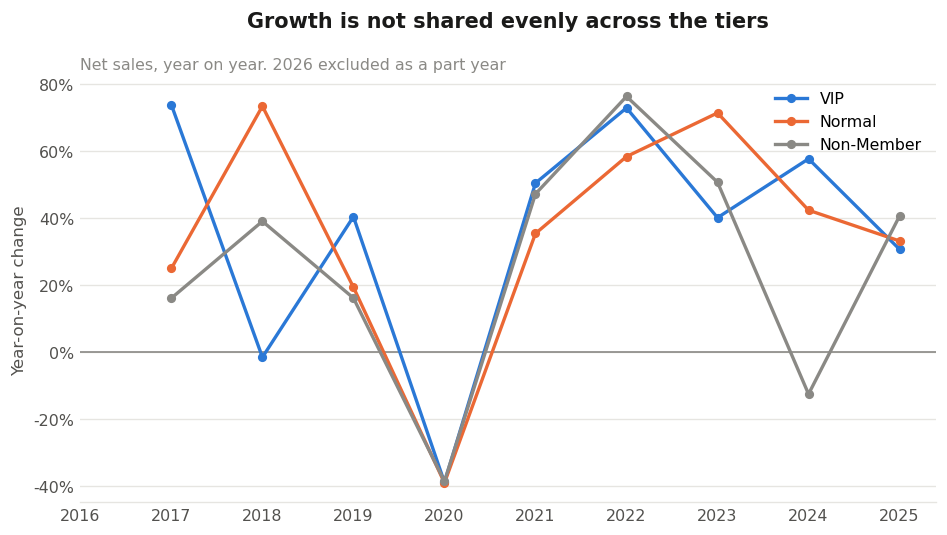

In [8]:
# %% ==============  CELL 8 - CHART c1_4: YEAR-ON-YEAR BY TIER  ===============
full = pivot.loc[pivot.index != PART_YEAR]          # part year cannot carry YoY
yoy = full.pct_change() * 100

fig, ax = plt.subplots(figsize=(9.2, 4.6))
for t in order:
    if t not in yoy.columns:
        continue
    ax.plot(yoy.index, yoy[t], marker="o", markersize=4.5, linewidth=2,
            label=t, color=TIER_COLOUR.get(t, GRID), zorder=3)

ax.axhline(0, color=INK_MUTE, linewidth=1, zorder=2)
ax.set_xticks(list(full.index))
ax.yaxis.set_major_formatter(pct)
ax.set_ylabel("Year-on-year change")
ax.set_title("Growth is not shared evenly across the tiers")
subtitle(ax, f"Net sales, year on year. {PART_YEAR} excluded as a part year")
ax.legend(loc="best")
clean(ax)
save(fig, "c1_4_yoy_by_tier")
plt.show()

## 4 - Report 2: Loyalty points liability

**Chart c2_1** the standing position - issued, redeemed, and the gap still owed. A
two-bar comparison, not a time series, because the liability question does not need one.

**Chart c2_2** participation by tier: the share of point-holding members who have ever
redeemed even once. This is the honest denominator - a points-weighted redemption rate
can be swung by a handful of large redemptions, participation cannot.

In [9]:
# %% ===============  CELL 9 - R2 DATA: POINTS BY TIER  =======================
pts = q("points_by_tier", """
    WITH holders AS (
        SELECT c.customer_id,
               MAX(c.membership_type) KEEP (DENSE_RANK LAST ORDER BY c.version_no)
                   AS membership,
               SUM(p.points_earned)   AS earned,
               SUM(p.points_redeemed) AS redeemed
        FROM   point_fact   p
        JOIN   customer_dim c ON c.customer_key = p.customer_key
        WHERE  p.customer_key <> -1
        GROUP  BY c.customer_id
    )
    SELECT membership,
           COUNT(*)                                       AS point_holders,
           SUM(CASE WHEN redeemed > 0 THEN 1 ELSE 0 END)  AS ever_redeemed,
           ROUND(100 * SUM(CASE WHEN redeemed > 0 THEN 1 ELSE 0 END)
                 / NULLIF(COUNT(*),0), 1)                 AS participation_pct,
           SUM(earned)                                    AS earned,
           SUM(redeemed)                                  AS redeemed,
           SUM(earned - redeemed)                         AS balance
    FROM   holders
    GROUP  BY membership
    ORDER  BY balance DESC
""")
pts

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20708\3712593257.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, _conn)


,MEMBERSHIP,POINT_HOLDERS,EVER_REDEEMED,PARTICIPATION_PCT,EARNED,REDEEMED,BALANCE
0,VIP,291,89,30.6,342790,22432,320358
1,Normal,354,58,16.4,217684,11643,206041


saved ..\..\Task 3 output\Yong Vay\c2_1_liability_position.png


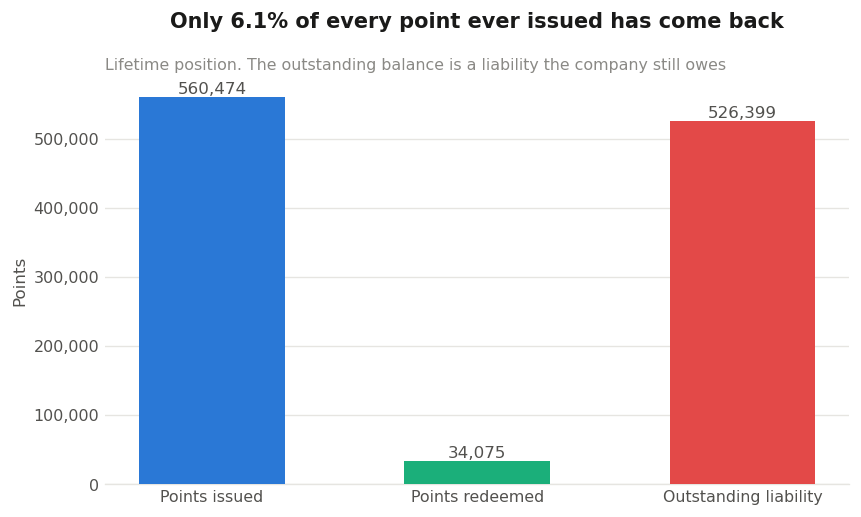

In [10]:
# %% ==========  CELL 10 - CHART c2_1: ISSUED, REDEEMED, OUTSTANDING  =========
issued      = float(pts["EARNED"].sum())
redeemed    = float(pts["REDEEMED"].sum())
outstanding = issued - redeemed

fig, ax = plt.subplots(figsize=(8.0, 4.4))
labels = ["Points issued", "Points redeemed", "Outstanding liability"]
vals   = [issued, redeemed, outstanding]
bars   = ax.bar(labels, vals, 0.55, color=[C1, C3, RED], zorder=3)

for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,.0f}",
            ha="center", va="bottom", fontsize=10, color=INK_SOFT)

ax.yaxis.set_major_formatter(rm)
ax.set_ylabel("Points")
rate = 100 * redeemed / issued if issued else 0
ax.set_title(f"Only {rate:.1f}% of every point ever issued has come back")
subtitle(ax, "Lifetime position. The outstanding balance is a liability the company still owes")
clean(ax)
save(fig, "c2_1_liability_position")
plt.show()

saved ..\..\Task 3 output\Yong Vay\c2_2_participation.png


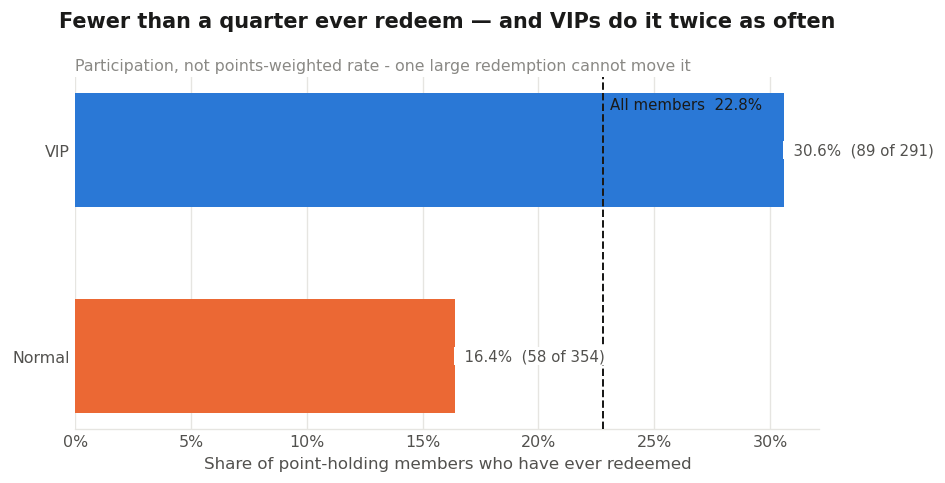

In [11]:
# %% ==============  CELL 11 - CHART c2_2: PARTICIPATION BY TIER  =============
# Non-members never earn points, so they have no participation to plot.
d = pts[pts["POINT_HOLDERS"] > 0].sort_values("PARTICIPATION_PCT", ascending=True)
colours = [TIER_COLOUR.get(t, GRID) for t in d["MEMBERSHIP"]]

fig, ax = plt.subplots(figsize=(8.0, 3.8))
bars = ax.barh(d["MEMBERSHIP"], d["PARTICIPATION_PCT"], 0.55,
               color=colours, zorder=3)

overall = 100 * d["EVER_REDEEMED"].sum() / d["POINT_HOLDERS"].sum()
ax.axvline(overall, color=INK, linewidth=1.2, linestyle="--", zorder=4)
ax.annotate(f"All members  {overall:.1f}%",
            xy=(overall, 1.0), xycoords=("data", "axes fraction"),
            xytext=(4, -12), textcoords="offset points",
            fontsize=9, color=INK, va="top")

for b, v, n, h in zip(bars, d["PARTICIPATION_PCT"],
                      d["EVER_REDEEMED"], d["POINT_HOLDERS"]):
    ax.text(v, b.get_y() + b.get_height()/2, f"  {v:.1f}%  ({n:,} of {h:,})",
            va="center", fontsize=9, color=INK_SOFT, zorder=5,
            bbox=dict(facecolor=SURFACE, edgecolor="none", pad=0.8))

ax.xaxis.set_major_formatter(pct)
ax.set_xlabel("Share of point-holding members who have ever redeemed")
ax.set_title("Fewer than a quarter ever redeem — and VIPs do it twice as often")
subtitle(ax, "Participation, not points-weighted rate - one large redemption cannot move it")
clean(ax, xgrid=True, ygrid=False)
save(fig, "c2_2_participation")
plt.show()

**Chart c2_3** where the liability sits. Each tier's share of the outstanding balance
plotted against its share of the membership - VIP earns at 2.00 points per ringgit
against Normal's 1.00, so the two shares should not match, and the gap is the number
that turns Report 1's repricing question into evidence.

**Chart c2_4** the monthly series, and the only chart in Report 2 with a time axis. It
starts at the all-branches era deliberately: in the source a member holds at most one
redemption dated at their most recent earn, so a series running from 2016 would describe
the data generator rather than the business. Read the cumulative balance line.

saved ..\..\Task 3 output\Yong Vay\c2_3_liability_by_tier.png


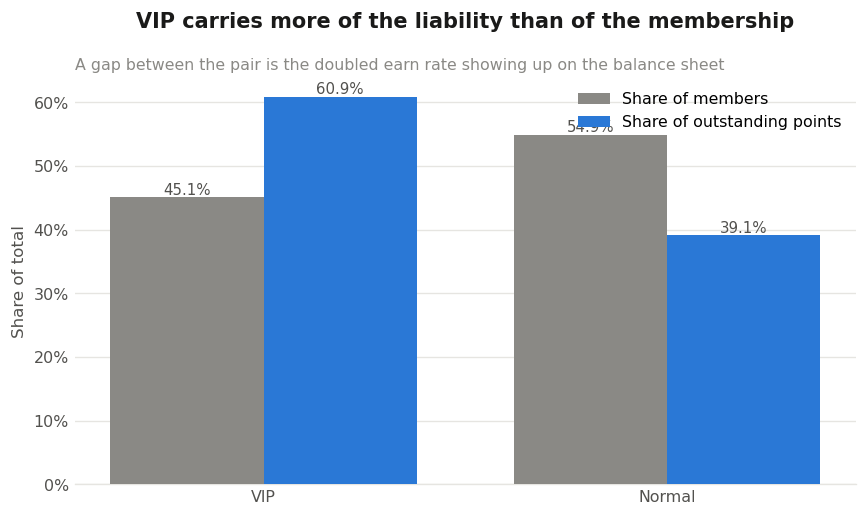

In [12]:
# %% ==========  CELL 12 - CHART c2_3: LIABILITY SHARE vs MEMBER SHARE  =======
d = pts.copy()
d["MEMBER_SHARE"]    = 100 * d["POINT_HOLDERS"] / d["POINT_HOLDERS"].sum()
d["LIABILITY_SHARE"] = 100 * d["BALANCE"] / d["BALANCE"].sum()
d = d.sort_values("LIABILITY_SHARE", ascending=False)

x = np.arange(len(d))
w = 0.38
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(x - w/2, d["MEMBER_SHARE"], w, label="Share of members",
       color=INK_MUTE, zorder=3)
ax.bar(x + w/2, d["LIABILITY_SHARE"], w, label="Share of outstanding points",
       color=C1, zorder=3)

for xi, (m, l) in enumerate(zip(d["MEMBER_SHARE"], d["LIABILITY_SHARE"])):
    ax.text(xi - w/2, m, f"{m:.1f}%", ha="center", va="bottom",
            fontsize=9, color=INK_SOFT)
    ax.text(xi + w/2, l, f"{l:.1f}%", ha="center", va="bottom",
            fontsize=9, color=INK_SOFT)

ax.set_xticks(x)
ax.set_xticklabels(d["MEMBERSHIP"])
ax.yaxis.set_major_formatter(pct)
ax.set_ylabel("Share of total")
ax.set_title("VIP carries more of the liability than of the membership")
subtitle(ax, "A gap between the pair is the doubled earn rate showing up on the balance sheet")
ax.legend(loc="upper right")
clean(ax)
save(fig, "c2_3_liability_by_tier")
plt.show()

In [13]:
# %% ==============  CELL 13 - R2 DATA: MONTHLY EARN vs REDEEM  ===============
monthly = q("points_monthly", f"""
    SELECT d.cal_year_month,
           SUM(p.points_earned)   AS points_earned,
           SUM(p.points_redeemed) AS points_redeemed,
           SUM(p.net_points)      AS net_points
    FROM   point_fact p
    JOIN   date_dim   d ON d.date_key = p.trans_date_key
    WHERE  p.customer_key <> -1
    AND    d.cal_year >= {ERA_YEAR}
    GROUP  BY d.cal_year_month
    ORDER  BY d.cal_year_month
""").sort_values("CAL_YEAR_MONTH")

monthly["CUMULATIVE"] = monthly["NET_POINTS"].cumsum()
monthly.tail()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20708\3712593257.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, _conn)


,CAL_YEAR_MONTH,POINTS_EARNED,POINTS_REDEEMED,NET_POINTS,CUMULATIVE
28,2026-05,10684,2991,7693,258608
29,2026-06,12374,3383,8991,267599
30,2026-07,7919,594,7325,274924
31,2026-08,5219,794,4425,279349
32,2026-09,3923,748,3175,282524


saved ..\..\Task 3 output\Yong Vay\c2_4_monthly_earn_redeem.png


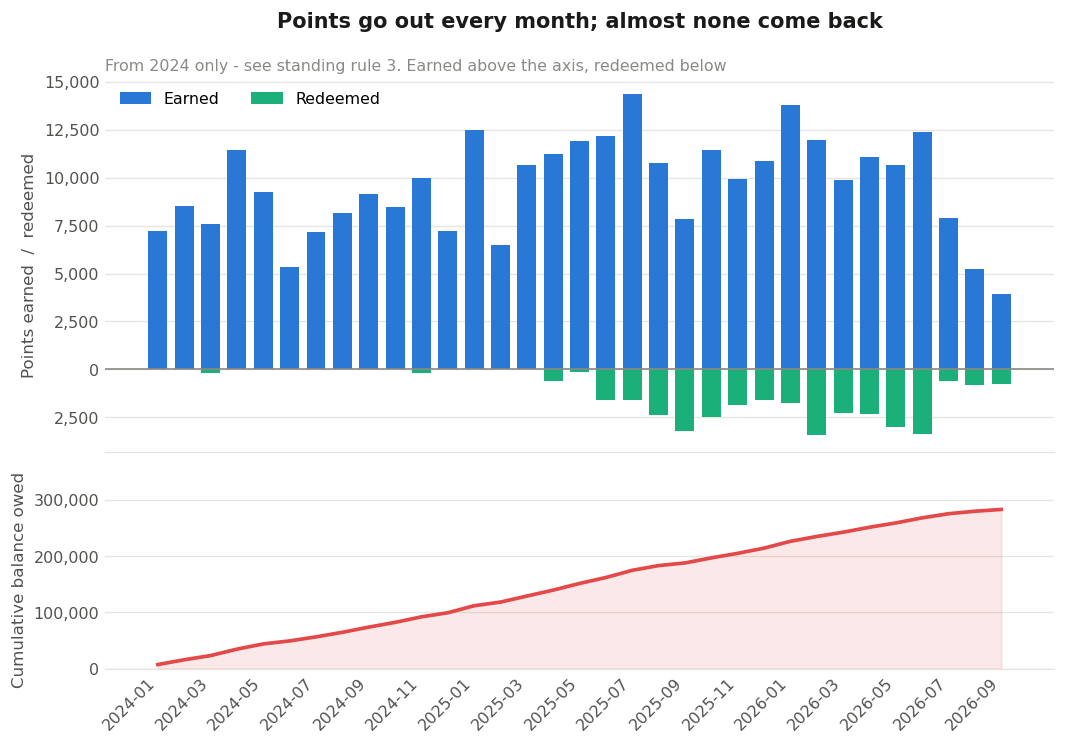

In [14]:
# %% =========  CELL 14 - CHART c2_4: MONTHLY EARN, REDEEM, BALANCE  ==========
# Two stacked panels rather than a twin axis. A twinned second scale would put
# the balance line across the bars at a zero that is not its own, which reads
# as a crossing that never happens.
m = monthly
x = np.arange(len(m))

fig, (ax, axb) = plt.subplots(
    2, 1, figsize=(10.2, 6.4), sharex=True,
    gridspec_kw=dict(height_ratios=[2.1, 1.0], hspace=0.14))

ax.bar(x,  m["POINTS_EARNED"],   0.72, label="Earned",   color=C1, zorder=3)
ax.bar(x, -m["POINTS_REDEEMED"], 0.72, label="Redeemed", color=C3, zorder=3)
ax.axhline(0, color=INK_MUTE, linewidth=1, zorder=4)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{abs(v):,.0f}"))
ax.set_ylabel("Points earned  /  redeemed")
ax.set_title("Points go out every month; almost none come back")
subtitle(ax, f"From {ERA_YEAR} only - see standing rule 3. Earned above the axis, redeemed below")
ax.legend(loc="upper left", ncols=2)
clean(ax)

axb.fill_between(x, m["CUMULATIVE"], color=RED, alpha=0.12, zorder=2)
axb.plot(x, m["CUMULATIVE"], color=RED, linewidth=2.2, zorder=3)
axb.set_ylim(0, m["CUMULATIVE"].max() * 1.12)
axb.yaxis.set_major_formatter(rm)
axb.set_ylabel("Cumulative balance owed")
clean(axb)

step = max(1, len(m) // 14)
axb.set_xticks(x[::step])
axb.set_xticklabels(m["CAL_YEAR_MONTH"].iloc[::step], rotation=45, ha="right")
save(fig, "c2_4_monthly_earn_redeem")
plt.show()

## 5 - Report 3: Retention and dormancy

Two definitions this section commits to, both stated because they are choices:

- **A customer's state** is the state of the branch they last shopped at. `customer_dim`
  holds no geography and `address_dim` only reaches `delivery_fact`, so branch is the
  available proxy - and it is the right one for a win-back campaign, which needs to know
  where someone shops now.
- **The as-at date** is the latest order date in the warehouse, not today's date, so the
  charts reproduce when the notebook is re-run on a rebuilt database.

**Chart c3_1** dormancy by state against the national average. The reference line is the
whole point: a bar above it is losing customers faster than the company as a whole,
which is the only comparison that justifies spending budget there rather than everywhere.

In [15]:
# %% ===============  CELL 15 - R3 DATA: DORMANCY BY STATE  ===================
state = q("dormancy_by_state", f"""
    WITH bounds AS (
        SELECT MAX(d.cal_date) AS as_of
        FROM   sales_fact s JOIN date_dim d ON d.date_key = s.order_date_key
    ), cust_last AS (
        SELECT c.customer_id, MAX(d.cal_date) AS last_order_date
        FROM   sales_fact   s
        JOIN   customer_dim c ON c.customer_key = s.customer_key
        JOIN   date_dim     d ON d.date_key     = s.order_date_key
        WHERE  c.customer_key <> -1 AND d.cal_year >= {ERA_YEAR}
        GROUP  BY c.customer_id
    ), cust_state AS (
        SELECT customer_id, branch_state
        FROM ( SELECT c.customer_id, b.branch_state,
                      ROW_NUMBER() OVER (PARTITION BY c.customer_id
                                         ORDER BY s.order_date_key DESC) AS rn
               FROM   sales_fact   s
               JOIN   customer_dim c ON c.customer_key = s.customer_key
               JOIN   branch_dim   b ON b.branch_key   = s.branch_key
               JOIN   date_dim     d ON d.date_key     = s.order_date_key
               WHERE  c.customer_key <> -1 AND b.branch_key <> -1
               AND    d.cal_year >= {ERA_YEAR} )
        WHERE  rn = 1
    )
    SELECT cs.branch_state,
           COUNT(*) AS base_customers,
           SUM(CASE WHEN MONTHS_BETWEEN(bo.as_of, cl.last_order_date) > 6
                    THEN 1 ELSE 0 END) AS dormant,
           ROUND(100 * SUM(CASE WHEN MONTHS_BETWEEN(bo.as_of, cl.last_order_date) > 6
                                THEN 1 ELSE 0 END) / COUNT(*), 1) AS dormancy_pct
    FROM   cust_last  cl
    JOIN   cust_state cs ON cs.customer_id = cl.customer_id
    CROSS  JOIN bounds bo
    GROUP  BY cs.branch_state
    ORDER  BY dormancy_pct DESC
""")
state

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20708\3712593257.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, _conn)


,BRANCH_STATE,BASE_CUSTOMERS,DORMANT,DORMANCY_PCT
0,Negeri Sembilan,80,44,55.0
1,Johor,77,41,53.2
2,Pahang,83,42,50.6
3,Selangor,166,84,50.6
4,Kedah,77,37,48.1
5,Kuala Lumpur,154,72,46.8
6,Perak,81,36,44.4
7,Melaka,81,35,43.2
8,Sarawak,79,32,40.5
9,Pulau Pinang,86,34,39.5


saved ..\..\Task 3 output\Yong Vay\c3_1_dormancy_by_state.png


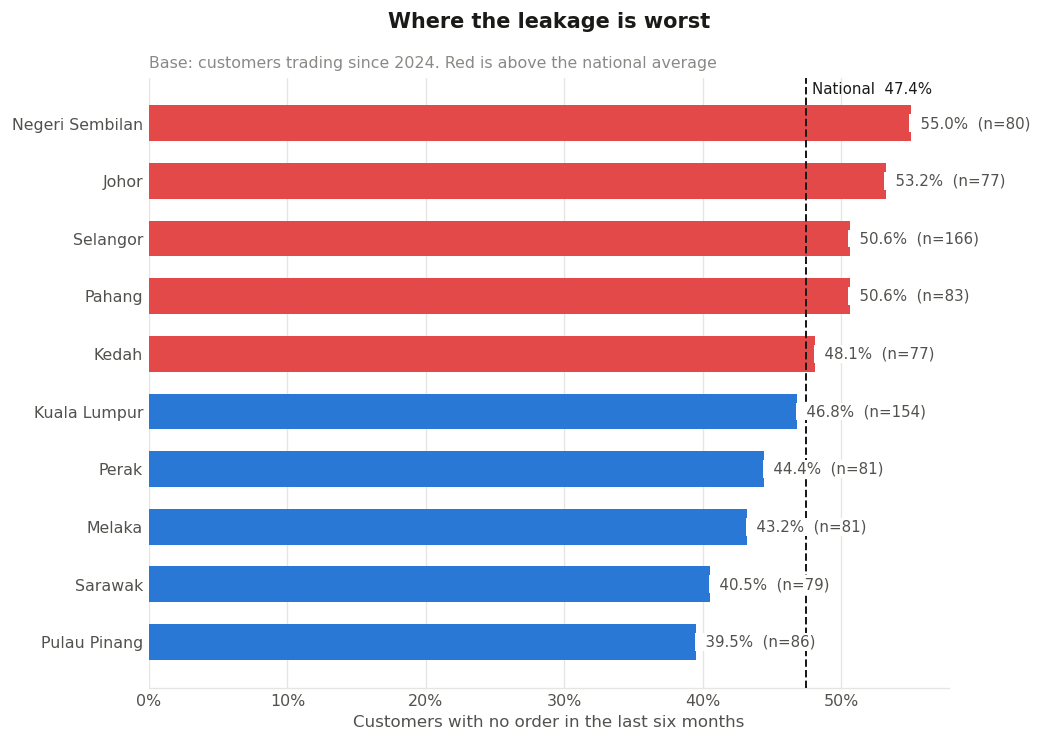

In [16]:
# %% =============  CELL 16 - CHART c3_1: DORMANCY BY STATE  ==================
d = state.sort_values("DORMANCY_PCT", ascending=True)
national = 100 * d["DORMANT"].sum() / d["BASE_CUSTOMERS"].sum()

# Only states materially worse than the national line get the accent colour.
colours = [RED if v > national else C1 for v in d["DORMANCY_PCT"]]

fig, ax = plt.subplots(figsize=(8.6, 0.42 * len(d) + 2.4))
bars = ax.barh(d["BRANCH_STATE"], d["DORMANCY_PCT"], 0.62,
               color=colours, zorder=3)

ax.axvline(national, color=INK, linewidth=1.2, linestyle="--", zorder=4)
ax.annotate(f"National  {national:.1f}%", xy=(national, len(d) - 0.4),
            xytext=(4, 0), textcoords="offset points",
            fontsize=9, color=INK, va="center")

for b, v, n in zip(bars, d["DORMANCY_PCT"], d["BASE_CUSTOMERS"]):
    ax.text(v, b.get_y() + b.get_height()/2, f"  {v:.1f}%  (n={n:,})",
            va="center", fontsize=9, color=INK_SOFT, zorder=5,
            bbox=dict(facecolor=SURFACE, edgecolor="none", pad=0.8))

ax.xaxis.set_major_formatter(pct)
ax.set_xlabel("Customers with no order in the last six months")
ax.set_title("Where the leakage is worst")
subtitle(ax, f"Base: customers trading since {ERA_YEAR}. Red is above the national average")
clean(ax, xgrid=True, ygrid=False)
save(fig, "c3_1_dormancy_by_state")
plt.show()

**Chart c3_2** the trading base month by month - customers who actually placed an order,
not customers who are merely registered, so a signed-up customer who never shops again is
correctly absent.

**Chart c3_3** retention by tier. This is the chart that closes the loop with Report 1:
Report 1 asked whether VIP *spends* more, this asks whether VIP *stays*. A tier that
spends more but churns at the same rate is buying revenue, not loyalty.

In [17]:
# %% ==============  CELL 17 - R3 DATA: ACTIVE BASE BY MONTH  =================
active = q("active_by_month", """
    SELECT d.cal_year_month,
           COUNT(DISTINCT c.customer_id) AS active_customers,
           COUNT(DISTINCT s.order_no)    AS orders
    FROM   sales_fact   s
    JOIN   customer_dim c ON c.customer_key = s.customer_key
    JOIN   date_dim     d ON d.date_key     = s.order_date_key
    WHERE  c.customer_key <> -1
    GROUP  BY d.cal_year_month
    ORDER  BY d.cal_year_month
""").sort_values("CAL_YEAR_MONTH")
active.tail()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20708\3712593257.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, _conn)


,CAL_YEAR_MONTH,ACTIVE_CUSTOMERS,ORDERS
124,2026-05,123,129
125,2026-06,120,130
126,2026-07,89,92
127,2026-08,59,60
128,2026-09,58,62


saved ..\..\Task 3 output\Yong Vay\c3_2_active_by_month.png


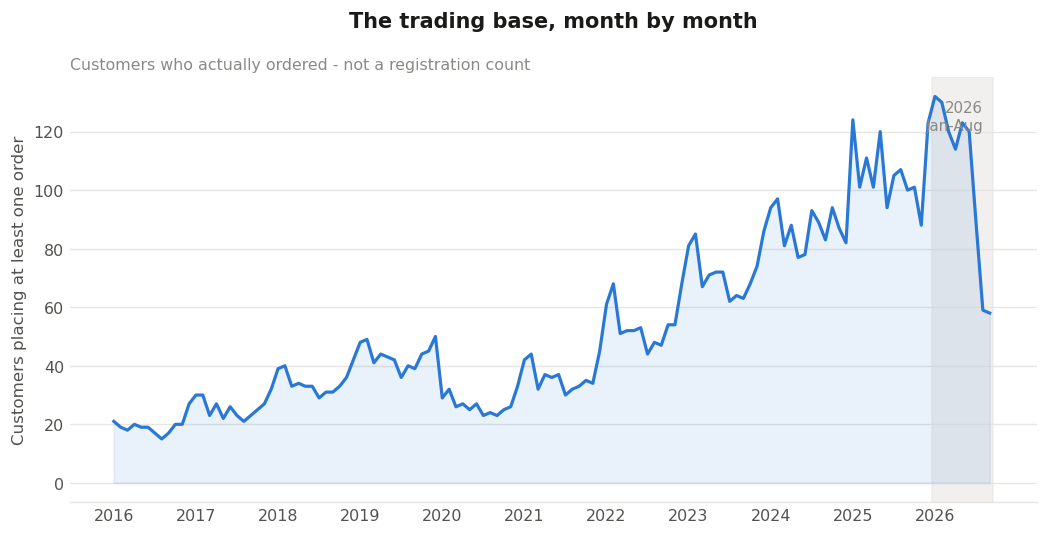

In [18]:
# %% ============  CELL 18 - CHART c3_2: ACTIVE BASE BY MONTH  ================
a = active
x = np.arange(len(a))
yr = a["CAL_YEAR_MONTH"].str.slice(0, 4).astype(int)

fig, ax = plt.subplots(figsize=(10.4, 4.6))
ax.plot(x, a["ACTIVE_CUSTOMERS"], color=C1, linewidth=1.9, zorder=3)
ax.fill_between(x, a["ACTIVE_CUSTOMERS"], color=C1, alpha=0.10, zorder=2)

# Shade the part year rather than truncating it - the shape is still real.
if (yr == PART_YEAR).any():
    lo = int(np.argmax((yr == PART_YEAR).to_numpy()))
    ax.axvspan(lo - 0.5, len(a) - 0.5, color=GRID, alpha=0.55, zorder=1)
    ax.annotate(f"{PART_YEAR}\nJan-Aug", xy=(len(a) - 1, ax.get_ylim()[1]),
                xytext=(-4, -14), textcoords="offset points",
                ha="right", va="top", fontsize=9, color=INK_MUTE)

ticks = [i for i in x if a["CAL_YEAR_MONTH"].iloc[i].endswith("01")]
ax.set_xticks(ticks)
ax.set_xticklabels([a["CAL_YEAR_MONTH"].iloc[i][:4] for i in ticks])
ax.yaxis.set_major_formatter(rm)
ax.set_ylabel("Customers placing at least one order")
ax.set_title("The trading base, month by month")
subtitle(ax, "Customers who actually ordered - not a registration count")
clean(ax)
save(fig, "c3_2_active_by_month")
plt.show()

In [19]:
# %% ==============  CELL 19 - R3 DATA: RETENTION BY TIER  ====================
ret_tier = q("retention_by_tier", f"""
    WITH bounds AS (
        SELECT MAX(d.cal_date) AS as_of
        FROM   sales_fact s JOIN date_dim d ON d.date_key = s.order_date_key
    ), cust_last AS (
        SELECT c.customer_id,
               MAX(d.cal_date) AS last_order_date,
               MAX(c.membership_type) KEEP (DENSE_RANK LAST ORDER BY c.version_no)
                   AS membership
        FROM   sales_fact   s
        JOIN   customer_dim c ON c.customer_key = s.customer_key
        JOIN   date_dim     d ON d.date_key     = s.order_date_key
        WHERE  c.customer_key <> -1 AND d.cal_year >= {ERA_YEAR}
        GROUP  BY c.customer_id
    )
    SELECT cl.membership,
           COUNT(*) AS base_customers,
           SUM(CASE WHEN MONTHS_BETWEEN(bo.as_of, cl.last_order_date) <= 6
                    THEN 1 ELSE 0 END) AS active,
           ROUND(100 * SUM(CASE WHEN MONTHS_BETWEEN(bo.as_of, cl.last_order_date) <= 6
                                THEN 1 ELSE 0 END) / COUNT(*), 1) AS retention_pct
    FROM   cust_last cl
    CROSS  JOIN bounds bo
    GROUP  BY cl.membership
    ORDER  BY retention_pct DESC
""")
ret_tier

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20708\3712593257.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, _conn)


,MEMBERSHIP,BASE_CUSTOMERS,ACTIVE,RETENTION_PCT
0,VIP,288,162,56.3
1,Normal,346,186,53.8
2,Non-Member,330,159,48.2


saved ..\..\Task 3 output\Yong Vay\c3_3_retention_by_tier.png


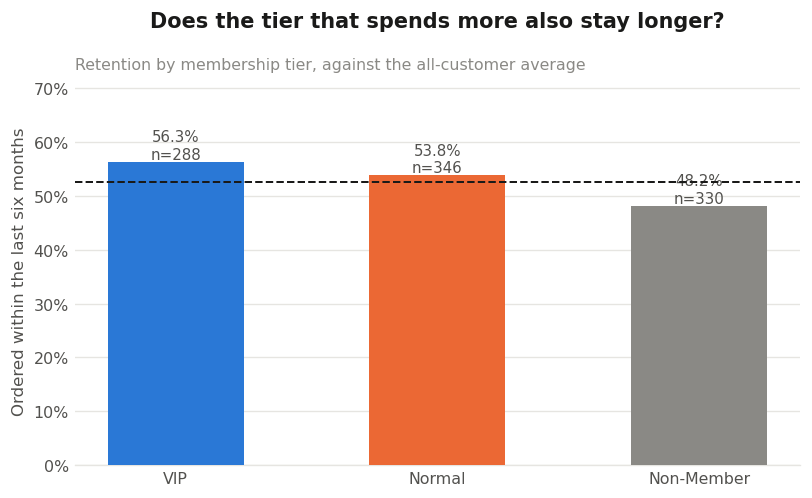

In [20]:
# %% ============  CELL 20 - CHART c3_3: RETENTION BY TIER  ===================
d = ret_tier.sort_values("RETENTION_PCT", ascending=False)
colours = [TIER_COLOUR.get(t, GRID) for t in d["MEMBERSHIP"]]

fig, ax = plt.subplots(figsize=(7.8, 4.2))
bars = ax.bar(d["MEMBERSHIP"], d["RETENTION_PCT"], 0.52,
              color=colours, zorder=3)

overall = 100 * d["ACTIVE"].sum() / d["BASE_CUSTOMERS"].sum()
ax.axhline(overall, color=INK, linewidth=1.2, linestyle="--", zorder=4)
ax.annotate(f"All customers  {overall:.1f}%", xy=(len(d) - 0.5, overall),
            xytext=(0, 5), textcoords="offset points",
            ha="right", fontsize=9, color=INK, zorder=5,
            bbox=dict(facecolor=SURFACE, edgecolor="none", pad=0.8))

for b, v, n in zip(bars, d["RETENTION_PCT"], d["BASE_CUSTOMERS"]):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:.1f}%\nn={n:,}",
            ha="center", va="bottom", fontsize=9, color=INK_SOFT, zorder=5,
            bbox=dict(facecolor=SURFACE, edgecolor="none", pad=0.8))

ax.yaxis.set_major_formatter(pct)
ax.set_ylabel("Ordered within the last six months")
ax.set_ylim(0, max(d["RETENTION_PCT"]) * 1.28)
ax.set_title("Does the tier that spends more also stay longer?")
subtitle(ax, "Retention by membership tier, against the all-customer average")
clean(ax)
save(fig, "c3_3_retention_by_tier")
plt.show()

**Chart c3_4** recency bands. How far gone the dormant base is decides what to spend on
it: a customer three months quiet needs a nudge, one two years quiet needs a
reacquisition offer or writing off.

**Chart c3_5** acquisition cohorts - grouping by the year of a customer's first order
shows whether retention is a recent problem or a long-standing one.

In [21]:
# %% ===============  CELL 21 - R3 DATA: RECENCY AND COHORTS  =================
recency = q("recency_bands", f"""
    WITH bounds AS (
        SELECT MAX(d.cal_date) AS as_of
        FROM   sales_fact s JOIN date_dim d ON d.date_key = s.order_date_key
    ), cust_last AS (
        SELECT c.customer_id, MAX(d.cal_date) AS last_order_date
        FROM   sales_fact   s
        JOIN   customer_dim c ON c.customer_key = s.customer_key
        JOIN   date_dim     d ON d.date_key     = s.order_date_key
        WHERE  c.customer_key <> -1 AND d.cal_year >= {ERA_YEAR}
        GROUP  BY c.customer_id
    )
    SELECT CASE WHEN MONTHS_BETWEEN(bo.as_of, cl.last_order_date) <=  3
                     THEN '1. 0 to 3 months'
                WHEN MONTHS_BETWEEN(bo.as_of, cl.last_order_date) <=  6
                     THEN '2. 3 to 6 months'
                WHEN MONTHS_BETWEEN(bo.as_of, cl.last_order_date) <= 12
                     THEN '3. 6 to 12 months'
                WHEN MONTHS_BETWEEN(bo.as_of, cl.last_order_date) <= 24
                     THEN '4. 12 to 24 months'
                ELSE '5. Over 24 months'
           END      AS recency_band,
           COUNT(*) AS customers
    FROM   cust_last cl CROSS JOIN bounds bo
    GROUP  BY CASE WHEN MONTHS_BETWEEN(bo.as_of, cl.last_order_date) <=  3
                        THEN '1. 0 to 3 months'
                   WHEN MONTHS_BETWEEN(bo.as_of, cl.last_order_date) <=  6
                        THEN '2. 3 to 6 months'
                   WHEN MONTHS_BETWEEN(bo.as_of, cl.last_order_date) <= 12
                        THEN '3. 6 to 12 months'
                   WHEN MONTHS_BETWEEN(bo.as_of, cl.last_order_date) <= 24
                        THEN '4. 12 to 24 months'
                   ELSE '5. Over 24 months'
              END
    ORDER  BY recency_band
""")

cohort = q("cohorts", """
    WITH bounds AS (
        SELECT MAX(d.cal_date) AS as_of
        FROM   sales_fact s JOIN date_dim d ON d.date_key = s.order_date_key
    ), cust_life AS (
        SELECT c.customer_id,
               MIN(d.cal_year) AS cohort_year,
               MAX(d.cal_date) AS last_order_date,
               SUM(s.net_sales_amt) AS lifetime_sales
        FROM   sales_fact   s
        JOIN   customer_dim c ON c.customer_key = s.customer_key
        JOIN   date_dim     d ON d.date_key     = s.order_date_key
        WHERE  c.customer_key <> -1
        GROUP  BY c.customer_id
    )
    SELECT cl.cohort_year,
           COUNT(*) AS customers_acquired,
           ROUND(100 * SUM(CASE WHEN MONTHS_BETWEEN(bo.as_of, cl.last_order_date) <= 6
                                THEN 1 ELSE 0 END) / COUNT(*), 1) AS still_active_pct,
           ROUND(AVG(cl.lifetime_sales), 2) AS avg_lifetime_sales
    FROM   cust_life cl CROSS JOIN bounds bo
    GROUP  BY cl.cohort_year
    ORDER  BY cl.cohort_year
""")
recency

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20708\3712593257.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, _conn)


,RECENCY_BAND,CUSTOMERS
0,1. 0 to 3 months,289
1,2. 3 to 6 months,218
2,3. 6 to 12 months,253
3,4. 12 to 24 months,165
4,5. Over 24 months,39


saved ..\..\Task 3 output\Yong Vay\c3_4_recency_bands.png


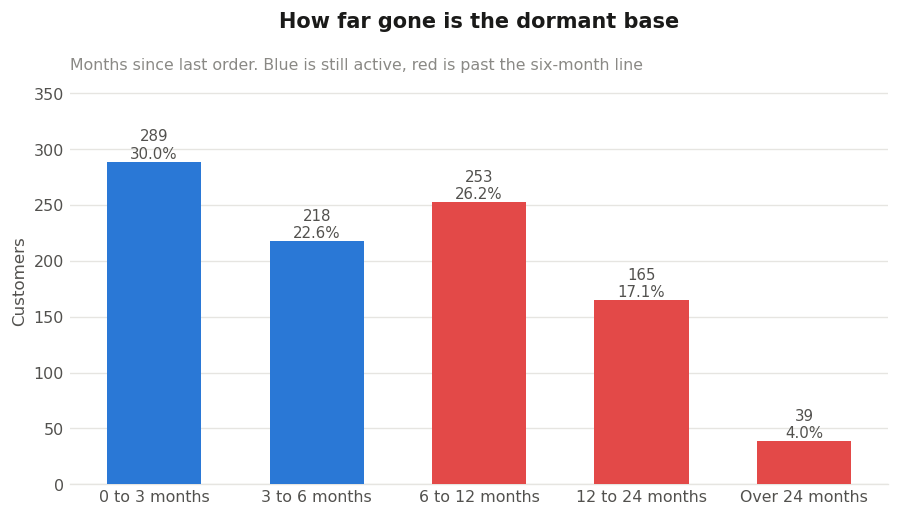

In [22]:
# %% ==============  CELL 22 - CHART c3_4: RECENCY BANDS  =====================
d = recency.sort_values("RECENCY_BAND")
labels = [b.split(". ", 1)[1] for b in d["RECENCY_BAND"]]
total = d["CUSTOMERS"].sum()

# Active bands in blue, dormant bands in red - the six-month line is the split.
# Keyed on the band prefix, so a band with no customers cannot shift the colours.
BAND_COLOUR = {"1": C1, "2": C1, "3": RED, "4": RED, "5": RED}
colours = [BAND_COLOUR.get(b[0], GRID) for b in d["RECENCY_BAND"]]

fig, ax = plt.subplots(figsize=(8.8, 4.4))
bars = ax.bar(labels, d["CUSTOMERS"], 0.58, color=colours, zorder=3)

for b, v in zip(bars, d["CUSTOMERS"]):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,}\n{100*v/total:.1f}%",
            ha="center", va="bottom", fontsize=9, color=INK_SOFT)

ax.yaxis.set_major_formatter(rm)
ax.set_ylabel("Customers")
ax.set_ylim(0, d["CUSTOMERS"].max() * 1.26)
ax.set_title("How far gone is the dormant base")
subtitle(ax, "Months since last order. Blue is still active, red is past the six-month line")
clean(ax)
save(fig, "c3_4_recency_bands")
plt.show()

saved ..\..\Task 3 output\Yong Vay\c3_5_cohorts.png


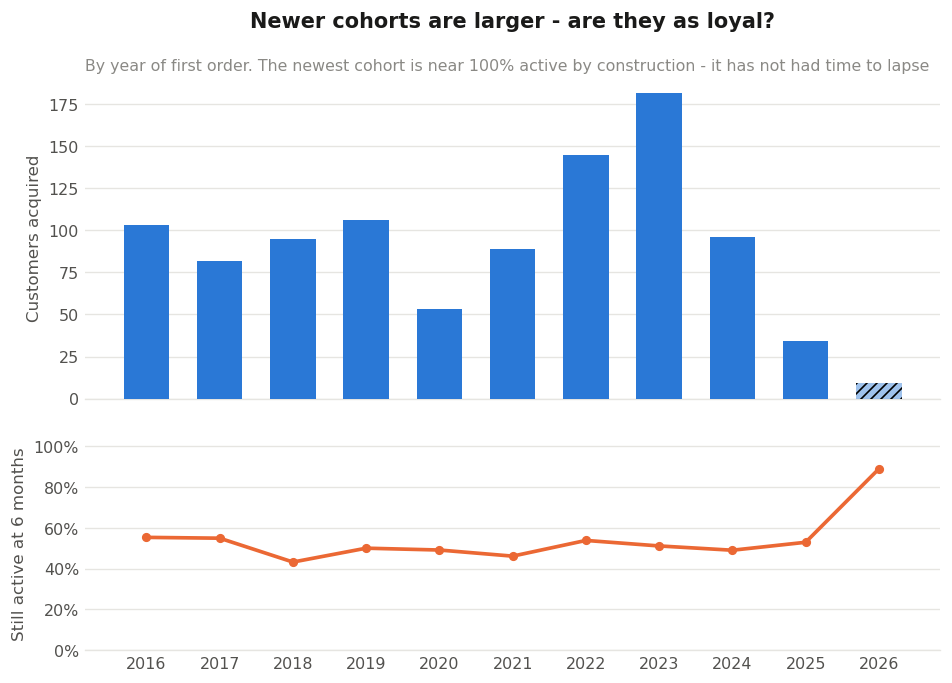

In [23]:
# %% ============  CELL 23 - CHART c3_5: ACQUISITION COHORTS  =================
# Stacked panels again, for the same reason as c2_4.
d = cohort.sort_values("COHORT_YEAR")

fig, (ax, axb) = plt.subplots(
    2, 1, figsize=(9.2, 6.2), sharex=True,
    gridspec_kw=dict(height_ratios=[1.5, 1.0], hspace=0.14))

bars = ax.bar(d["COHORT_YEAR"], d["CUSTOMERS_ACQUIRED"], 0.62,
              color=C1, zorder=3)
if PART_YEAR in list(d["COHORT_YEAR"]):
    i = list(d["COHORT_YEAR"]).index(PART_YEAR)
    bars[i].set_hatch("////")
    bars[i].set_alpha(0.45)
ax.yaxis.set_major_formatter(rm)
ax.set_ylabel("Customers acquired")
ax.set_title("Newer cohorts are larger - are they as loyal?")
subtitle(ax, f"By year of first order. The newest cohort is near 100% active by "
             f"construction - it has not had time to lapse")
clean(ax)

axb.plot(d["COHORT_YEAR"], d["STILL_ACTIVE_PCT"], color=C2, linewidth=2.2,
         marker="o", markersize=4.5, zorder=3)
axb.set_ylim(0, 105)
axb.yaxis.set_major_formatter(pct)
axb.set_ylabel("Still active at 6 months")
axb.set_xticks(list(d["COHORT_YEAR"]))
clean(axb)
save(fig, "c3_5_cohorts")
plt.show()

## 6 - Close

Every chart is written to `Task 3 output/Yong Vay/`, named so the filename maps onto the
exhibit it illustrates (`c1_1`, `c2_4`, `c3_3` and so on). Nothing in this notebook holds
a transcribed figure - re-run the ETL, re-run the notebook, and the charts follow.

In [24]:
# %% ===========================  CELL 24 - CLOSE  ============================
if _conn is not None:
    _conn.close()
    print("Connection closed.")

print("\nCharts written to", os.path.abspath(OUT))
for f in sorted(os.listdir(OUT)):
    if f.endswith(".png"):
        print("  ", f)

Connection closed.

Charts written to c:\Users\Lenovo\Desktop\Database Warehouse\data-warehouse-assignment\Task 3 output\Yong Vay
   c1_1_tier_value.png
   c1_2_sales_share.png
   c1_3_tier_by_year.png
   c1_4_yoy_by_tier.png
   c2_1_liability_position.png
   c2_2_participation.png
   c2_3_liability_by_tier.png
   c2_4_monthly_earn_redeem.png
   c3_1_dormancy_by_state.png
   c3_2_active_by_month.png
   c3_3_retention_by_tier.png
   c3_4_recency_bands.png
   c3_5_cohorts.png
